In [2]:
import pandas as pd
import numpy as np
import sys, os, re, random, json
from pathlib import Path

sys.path.append(os.path.join('..', 'ml-backend'))
from utils.feature_extractor import extract_features, extract_features_batch

random.seed(42)
np.random.seed(42)
print("Import berhasil!")

Import berhasil!


In [3]:
# Load konfigurasi dari config.json
CONFIG_PATH = Path('..') / 'ml-backend' / 'data' / 'config.json'

with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

KEYWORD_SLOT   = config['KEYWORDS']['GAMBLING']
GAMBLING_REGEX = config['REGEX_PATTERNS']['GAMBLING']

print("Config berhasil dimuat!")
print(f"  Keyword phishing : {len(config['KEYWORDS']['PHISHING'])} kata")
print(f"  Keyword gambling : {len(config['KEYWORDS']['GAMBLING'])} kata")
print(f"  Trusted brands   : {len(config['KEYWORDS']['TRUSTED_BRANDS'])} brand")
print(f"  Whitelist domain : {len(config['DOMAINS']['WHITELIST'])} domain")
print(f"  Blacklist domain : {len(config['DOMAINS']['BLACKLIST'])} domain")

Config berhasil dimuat!
  Keyword phishing : 23 kata
  Keyword gambling : 26 kata
  Trusted brands   : 20 brand
  Whitelist domain : 125 domain
  Blacklist domain : 5 domain


In [4]:
# Load data phishing
df_phishing_raw = pd.read_csv('../dataset/phishing_urls.csv')
print(f"Total phishing URL tersedia : {len(df_phishing_raw):,}")
print(f"Kolom                       : {df_phishing_raw.columns.tolist()}")
print()
print("Contoh URL phishing:")
print(df_phishing_raw.head(3).to_string(index=False))

Total phishing URL tersedia : 57,103
Kolom                       : ['url']

Contoh URL phishing:
                                      url
   http://allegrolokalne.pl-590120421.lol
         http://allegro.pl-5903241241.lol
http://allegro-lokalnie.pl-5903241241.lol


In [5]:
df_phishing = pd.DataFrame({
    'url'  : df_phishing_raw['url'],
    'label': 1
})
df_phishing = df_phishing.dropna().drop_duplicates()
df_phishing = df_phishing.head(5000)
print(f"Dataset phishing yang dipakai: {len(df_phishing)} URL")

Dataset phishing yang dipakai: 5000 URL


In [6]:
# Load data legitimate
df_top1m_raw = pd.read_csv('../dataset/top-1m.csv')

print(f"Total legitimate domain tersedia: {len(df_top1m_raw):,}")
print(f"Kolom: {df_top1m_raw.columns.tolist()}")
print()
print("Contoh isi:")
print(df_top1m_raw.head(5).to_string(index=False))

Total legitimate domain tersedia: 1,000,000
Kolom: ['url']

Contoh isi:
         url
  google.com
facebook.com
 youtube.com
   yahoo.com
   baidu.com


In [7]:
# ENRICHMENT URL LEGITIMATE
# Daftar path yang realistis untuk situs normal
REALISTIC_PATHS = [
    '', '/about', '/contact', '/products', '/search',
    '/home', '/news', '/article', '/blog', '/faq',
    '/help', '/login', '/register', '/profile',
    '/settings', '/dashboard',
]

# Daftar query string yang realistis
REALISTIC_QUERIES = [
    '', '?page=1', '?lang=id', '?ref=home',
    '?q=berita+terbaru', '?category=teknologi',
    '?id=123', '?tab=overview', '?sort=desc',
    '?utm_source=google',
]

def enrich_legitimate_url(domain):
    scheme = 'https://'

    if random.random() < 0.30:
        return f"{scheme}{domain}"

    path  = random.choice(REALISTIC_PATHS)
    query = random.choice(REALISTIC_QUERIES)

    return f"{scheme}{domain}{path}{query}"

df_legitimate = pd.DataFrame({
    'url'  : [enrich_legitimate_url(d) for d in df_top1m_raw['url'].head(6000)],
    'label': 0
})

df_legitimate = df_legitimate.dropna().drop_duplicates()
df_legitimate = df_legitimate.head(5000)

print(f"Dataset legitimate yang dipakai: {len(df_legitimate)} URL")
print()
print("Contoh URL legitimate (setelah enrichment):")
for url in df_legitimate['url'].sample(5, random_state=42).values:
    print(f"  {url}")

Dataset legitimate yang dipakai: 5000 URL

Contoh URL legitimate (setelah enrichment):
  https://blackboard.com
  https://list.ru
  https://topit.me
  https://grooveshark.com/profile?id=123
  https://123rf.com/home?lang=id


In [8]:
# Kampus-kampus Indonesia (ac.id)
KAMPUS_AC_ID = [
    'ugm', 'ui', 'itb', 'its', 'ipb', 'undip', 'unair', 'unpad',
    'upi', 'uny', 'unesa', 'unsri', 'unand', 'unhas', 'unsrat',
    'unmul', 'ulm', 'uho', 'unsoed', 'unnes', 'usu', 'unib',
    'unja', 'untan', 'unpatti', 'uncen', 'politala', 'poliban',
    'poltekba', 'poliupg', 'polimdo', 'polines', 'polman',
    'stmik', 'stie', 'stikes', 'amik', 'akademi',
]

# Subdomain yang wajar di situs kampus
SUBDOMAINS_KAMPUS = [
    '', 'www', 'siakad', 'sipadu', 'simak', 'akademik',
    'pmb', 'pendaftaran', 'library', 'perpustakaan',
    'elearning', 'lms', 'kuliah', 'portal', 'student',
    'mahasiswa', 'alumni', 'career', 'repository', 'repo',
    'jurnal', 'journal', 'mail', 'webmail', 'sso',
    'auth', 'id', 'siak', 'sia', 'simawa', 'simkeu',
]

# Instansi pemerintah (go.id)
PEMERINTAH_GO_ID = [
    'kemendikbud', 'kemenkes', 'kemenkeu', 'kemenperin',
    'kemendag', 'kementan', 'kemenpu', 'kemenhub',
    'kemenkominfo', 'kemenag', 'kemensetneg', 'kemenpora',
    'bappenas', 'bpkp', 'bps', 'bpom', 'bkkbn',
    'bnpb', 'bnpt', 'basarnas', 'bakamla',
    'setnas', 'setkab', 'setneg',
    'dprd', 'dprdprov', 'pemkot', 'pemkab', 'pemprov',
    'dinkes', 'disdik', 'diskominfo', 'dishub',
    'rsud', 'rscm', 'rsup', 'puskesmas',
]

# Subdomain yang wajar di situs pemerintah
SUBDOMAINS_GOV = [
    '', 'www', 'portal', 'layanan', 'sipd', 'simda',
    'sipp', 'eprocurement', 'lpse',
    'mail', 'webmail', 'sso', 'auth',
    'pelayanan', 'informasi', 'data', 'statistik',
    'aplikasi', 'sistem', 'simpeg', 'simrs',
]

# Path yang wajar di situs kampus/pemerintah
PATHS_INSTITUSI = [
    '', '/login', '/dashboard', '/profile', '/account',
    '/gate/login', '/auth/login', '/user/login',
    '/index.php', '/home', '/beranda', '/tentang',
    '/akademik', '/mahasiswa', '/dosen', '/penelitian',
    '/pengabdian', '/berita', '/news', '/pengumuman',
    '/jadwal', '/nilai', '/transkrip', '/krs',
    '/registrasi', '/pendaftaran', '/wisuda',
    '/perpustakaan', '/elearning', '/download',
    '/kontak', '/contact', '/faq', '/bantuan',
]

def generate_institusi_urls(n_target=2500, seed=42):
    random.seed(seed)
    urls = set()

    # URL kampus ac.id
    for kampus in KAMPUS_AC_ID:
        for sub in random.sample(SUBDOMAINS_KAMPUS, min(6, len(SUBDOMAINS_KAMPUS))):
            for path in random.sample(PATHS_INSTITUSI, min(5, len(PATHS_INSTITUSI))):
                url = f"https://{sub}.{kampus}.ac.id{path}" if sub else f"https://{kampus}.ac.id{path}"
                urls.add(url)

    # URL pemerintah go.id
    for instansi in PEMERINTAH_GO_ID:
        for sub in random.sample(SUBDOMAINS_GOV, min(5, len(SUBDOMAINS_GOV))):
            for path in random.sample(PATHS_INSTITUSI, min(4, len(PATHS_INSTITUSI))):
                url = f"https://{sub}.{instansi}.go.id{path}" if sub else f"https://{instansi}.go.id{path}"
                urls.add(url)

    url_list = list(urls)
    random.shuffle(url_list)
    return url_list[:n_target]

df_institusi = pd.DataFrame({
    'url'  : generate_institusi_urls(n_target=2500, seed=42),
    'label': 0, 
})

df_institusi = df_institusi.dropna().drop_duplicates(subset=['url'])

print(f"Dataset URL institusi Indonesia: {len(df_institusi)} URL")
print()
print("Contoh URL:")
for url in df_institusi['url'].sample(10, random_state=42).values:
    print(f"  {url}")

Dataset URL institusi Indonesia: 1880 URL

Contoh URL:
  https://jurnal.ugm.ac.id/auth/login
  https://simawa.unpad.ac.id/jadwal
  https://siakad.uncen.ac.id/perpustakaan
  https://sipp.pemprov.go.id/penelitian
  https://simrs.puskesmas.go.id/auth/login
  https://statistik.kemendikbud.go.id/news
  https://simrs.bappenas.go.id/pengumuman
  https://library.unib.ac.id/berita
  https://aplikasi.rscm.go.id/login
  https://portal.unpatti.ac.id


In [9]:
# Load data judol
df_gambling_raw = pd.read_csv('../dataset/gambling_urls.csv')

print(f"Total gambling URL di file: {len(df_gambling_raw):,}")
print(f"Kolom: {df_gambling_raw.columns.tolist()}")
print()
print("Contoh URL gambling dari file:")
print(df_gambling_raw.head(5).to_string(index=False))

Total gambling URL di file: 2,910
Kolom: ['url']

Contoh URL gambling dari file:
                          url
       http://data-togel.club
     https://agen-judi.online
http://casino-terpercaya.site
      https://togel-resmi.vip
     http://casino-online.xyz


In [10]:
# Generate url judol tambahan
GAMBLING_KW = config['KEYWORDS']['GAMBLING']

# Template URL judol yang realistis
TLD_JUDOL = ['.com', '.net', '.xyz', '.online', '.site',
             '.info', '.club', '.live', '.top', '.vip']

SUFFIX = ['', '88', '77', '99', '168', '365', '2024', '4d', '138', 'pro']

PROTOCOL = ['http://', 'https://']

JUDOL_PATHS = [
    '', '/daftar', '/login', '/promo',
    '/promo/bonus-new-member', '/game/slot',
    '/game/live-casino', '/deposit', '/withdraw',
    '/link-alternatif', '/daftar?ref=telegram',
    '/promo?bonus=100',
]

JUDOL_SUBDOMAINS = [
    '', 'www', 'link', 'daftar', 'login',
    'promo', 'alternatif', 'main', 'play', 'game',
]

def generate_gambling_urls(keywords, n_target=2500, seed=42):
    random.seed(seed)
    urls = set()

    for kw in keywords:
        for tld in TLD_JUDOL:
            for proto in PROTOCOL:
                urls.add(f"{proto}{kw}{tld}")
                for suffix in random.sample(SUFFIX, 3):
                    urls.add(f"{proto}{kw}{suffix}{tld}")
                sub = random.choice(JUDOL_SUBDOMAINS[1:])
                urls.add(f"{proto}{sub}.{kw}{tld}")
                path = random.choice(JUDOL_PATHS[1:])
                urls.add(f"{proto}{kw}{tld}{path}")

    url_list = list(urls)
    random.shuffle(url_list)
    return url_list[:n_target]

TARGET      = 5000
sudah_ada   = len(df_gambling_raw)
perlu_tambah = max(0, TARGET - sudah_ada + 200)

print(f"URL gambling dari file : {sudah_ada}")
print(f"Target total           : {TARGET}")
print(f"Perlu generate tambahan: {perlu_tambah}")
print()

# Generate URL tambahan
urls_tambahan = generate_gambling_urls(GAMBLING_KW, n_target=perlu_tambah, seed=42)

df_tambahan = pd.DataFrame({
    'url'  : urls_tambahan,
    'label': 2
})

df_gambling = pd.concat([
    pd.DataFrame({'url': df_gambling_raw['url'], 'label': 2}),
    df_tambahan
], ignore_index=True)

df_gambling = df_gambling.dropna().drop_duplicates(subset=['url'])
df_gambling = df_gambling.head(TARGET)

print(f"Dataset gambling final : {len(df_gambling)} URL")
print(f"  - Dari file gambling_urls.csv : {min(sudah_ada, TARGET)}")
print(f"  - Generate dari config keyword: {len(df_gambling) - min(sudah_ada, TARGET)}")
print()
print("Contoh URL gambling:")
for url in df_gambling['url'].sample(5, random_state=42).values:
    print(f"  {url}")

URL gambling dari file : 2910
Target total           : 5000
Perlu generate tambahan: 2290

Dataset gambling final : 5000 URL
  - Dari file gambling_urls.csv : 2910
  - Generate dari config keyword: 2090

Contoh URL gambling:
  https://mahjong-ways.com
  http://angka-jitu.top
  https://rtp-live2024.info
  https://togel-sydney.site
  http://slot-jackpot168.site


In [11]:
TARGET = 5000

df_aman_gabung = pd.concat(
    [df_legitimate, df_institusi],
    ignore_index=True
)
df_aman_gabung = df_aman_gabung.dropna().drop_duplicates(subset=['url'])
df_aman_gabung = df_aman_gabung.sample(frac=1, random_state=42).reset_index(drop=True)
df_aman_gabung = df_aman_gabung.head(TARGET)

print(f"Kelas AMAN total setelah digabung: {len(df_aman_gabung)} URL")
print(f"  - top-1m (situs umum)         : {len(df_legitimate)} URL")
print(f"  - Institusi Indonesia          : {len(df_institusi)} URL")
print()

df_phishing_balanced = df_phishing.head(TARGET)
df_gambling_balanced = df_gambling.head(TARGET)

df_all = pd.concat(
    [df_phishing_balanced, df_aman_gabung, df_gambling_balanced],
    ignore_index=True
)

df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total dataset gabungan : {len(df_all)} URL")
print()
print("Distribusi label (harus seimbang ~33% tiap kelas):")
counts    = df_all['label'].value_counts().sort_index()
label_map = {0: 'Aman (0)', 1: 'Phishing (1)', 2: 'Judi Online (2)'}
for label, count in counts.items():
    persen = count / len(df_all) * 100
    bar    = '█' * int(persen / 2)
    print(f"  {label_map[label]:<16}: {count} ({persen:.1f}%) {bar}")

print()
print("✅ Dataset seimbang! Masing-masing kelas ~5.000 URL (33%)")

Kelas AMAN total setelah digabung: 5000 URL
  - top-1m (situs umum)         : 5000 URL
  - Institusi Indonesia          : 1880 URL

Total dataset gabungan : 15000 URL

Distribusi label (harus seimbang ~33% tiap kelas):
  Aman (0)        : 5000 (33.3%) ████████████████
  Phishing (1)    : 5000 (33.3%) ████████████████
  Judi Online (2) : 5000 (33.3%) ████████████████

✅ Dataset seimbang! Masing-masing kelas ~5.000 URL (33%)


In [12]:
# Ekstraksi fitur
print("Memulai ekstraksi fitur dari", len(df_all), "URL...")

features_list = extract_features_batch(df_all['url'].tolist())
df_features   = pd.DataFrame(features_list)
df_features['label'] = df_all['label'].values

print(f"✅ Selesai! Shape dataset fitur: {df_features.shape}")
print(f"   Jumlah URL   : {df_features.shape[0]}")
print(f"   Jumlah fitur : {df_features.shape[1] - 1} (+ 1 kolom label)")
print()
print("3 baris pertama:")
print(df_features.head(3).to_string())

Memulai ekstraksi fitur dari 15000 URL...
✅ Selesai! Shape dataset fitur: (15000, 28)
   Jumlah URL   : 15000
   Jumlah fitur : 27 (+ 1 kolom label)

3 baris pertama:
   url_length  has_https  dot_count  hyphen_count  at_count  double_slash  digit_count  domain_length  path_depth  has_query  has_suspicious_tld  has_ip  has_phishing_keyword  has_gambling_keyword  has_brand_spoofing  subdomain_length  subdomain_count  domain_entropy  special_chars  path_length  digit_ratio_url  has_port  has_redirect  consonant_ratio  query_length  query_params  has_fragment  label
0          27          1          1             1         0             0            0             12           0          0                   1       0                     0                     0                   0                 0                0          3.1887              1            0              0.0         0             0           0.5455             0             0             0      2
1          21          1   

In [13]:
# Analisis fitur
label_names = {0: 'Aman', 1: 'Phishing', 2: 'Judi'}

fitur_cek = [
    'url_length', 'dot_count', 'domain_entropy',
    'has_https', 'has_suspicious_tld',
    'has_phishing_keyword', 'has_gambling_keyword',
    'subdomain_count', 'path_length',
]

print("=== Rata-rata Fitur per Kelas ===")
print("(Semakin berbeda antar kelas → semakin berguna untuk model)")
print()

for fitur in fitur_cek:
    print(f"{fitur}:")
    for label, nama in label_names.items():
        rata = df_features[df_features['label'] == label][fitur].mean()
        print(f"  {nama:<10}: {rata:.3f}")
    print()

=== Rata-rata Fitur per Kelas ===
(Semakin berbeda antar kelas → semakin berguna untuk model)

url_length:
  Aman      : 32.830
  Phishing  : 45.090
  Judi      : 23.664

dot_count:
  Aman      : 1.618
  Phishing  : 1.932
  Judi      : 1.075

domain_entropy:
  Aman      : 2.373
  Phishing  : 2.710
  Judi      : 2.890

has_https:
  Aman      : 1.000
  Phishing  : 0.903
  Judi      : 0.501

has_suspicious_tld:
  Aman      : 0.000
  Phishing  : 0.071
  Judi      : 0.497

has_phishing_keyword:
  Aman      : 0.012
  Phishing  : 0.050
  Judi      : 0.013

has_gambling_keyword:
  Aman      : 0.003
  Phishing  : 0.003
  Judi      : 0.950

subdomain_count:
  Aman      : 0.303
  Phishing  : 0.743
  Judi      : 0.067

path_length:
  Aman      : 5.653
  Phishing  : 8.979
  Judi      : 0.843



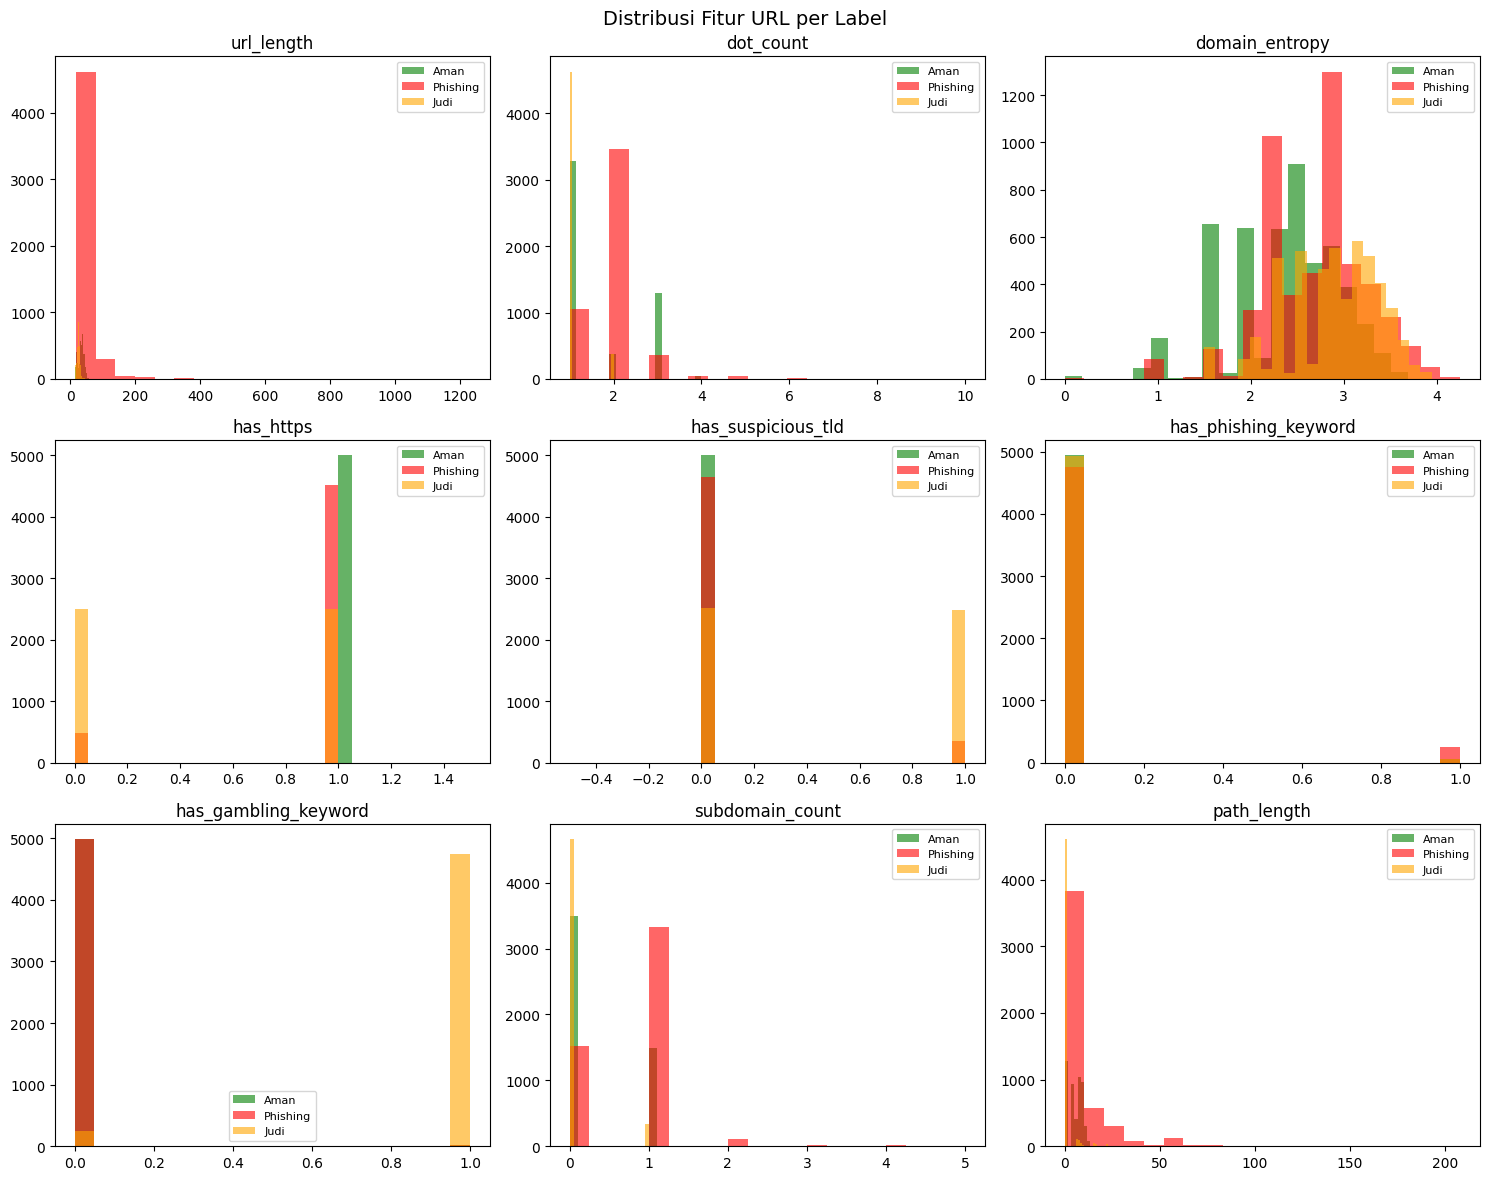

✅ Grafik distribusi fitur disimpan!


In [14]:
import matplotlib.pyplot as plt

colors = {0: 'green', 1: 'red', 2: 'orange'}

fitur_plot = [
    'url_length', 'dot_count', 'domain_entropy',
    'has_https', 'has_suspicious_tld', 'has_phishing_keyword',
    'has_gambling_keyword', 'subdomain_count', 'path_length',
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribusi Fitur URL per Label', fontsize=14)

for idx, fitur in enumerate(fitur_plot):
    ax = axes[idx // 3][idx % 3]
    for label, nama in label_names.items():
        data = df_features[df_features['label'] == label][fitur]
        ax.hist(data, alpha=0.6, label=nama, color=colors[label], bins=20)
    ax.set_title(fitur)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../dataset/feature_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Grafik distribusi fitur disimpan!")

In [15]:
# Menyimpan features_dataset
SAVE_PATH = '../ml-backend/data/features_dataset.csv'

df_features.to_csv(SAVE_PATH, index=False)

print(f"✅ Dataset fitur berhasil disimpan!")
print(f"   Path  : {SAVE_PATH}")
print(f"   Shape : {df_features.shape}")
print(f"   Kolom : {df_features.columns.tolist()}")
print()

# Verifikasi ulang distribusi di file yang disimpan
df_check = pd.read_csv(SAVE_PATH)
print("Verifikasi distribusi label di file yang disimpan:")
for label, nama in {0:'Aman', 1:'Phishing', 2:'Judi Online'}.items():
    count  = (df_check['label'] == label).sum()
    persen = count / len(df_check) * 100
    print(f"  {nama:<12}: {count} ({persen:.1f}%)")

✅ Dataset fitur berhasil disimpan!
   Path  : ../ml-backend/data/features_dataset.csv
   Shape : (15000, 28)
   Kolom : ['url_length', 'has_https', 'dot_count', 'hyphen_count', 'at_count', 'double_slash', 'digit_count', 'domain_length', 'path_depth', 'has_query', 'has_suspicious_tld', 'has_ip', 'has_phishing_keyword', 'has_gambling_keyword', 'has_brand_spoofing', 'subdomain_length', 'subdomain_count', 'domain_entropy', 'special_chars', 'path_length', 'digit_ratio_url', 'has_port', 'has_redirect', 'consonant_ratio', 'query_length', 'query_params', 'has_fragment', 'label']

Verifikasi distribusi label di file yang disimpan:
  Aman        : 5000 (33.3%)
  Phishing    : 5000 (33.3%)
  Judi Online : 5000 (33.3%)
